# IMPORT LIBRARIES

In [91]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from pmdarima import auto_arima, ARIMA, model_selection
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import  ParameterGrid
from sklearn.metrics import mean_squared_error, root_mean_squared_log_error, r2_score, mean_absolute_percentage_error, mean_absolute_error


# Import data and perform cleaning

In [92]:
df= pd.read_csv(r"C:\Users\MINE\Desktop\Nigerian Stock Exchange (NGX) All-Share Index\NSE All Share Historical Data (1).csv")

In [93]:
df.head(10)

,Date,Price,Open,High,Low,Vol.,Change %
0,10/02/2026,"176,805.95","173,946.22","177,094.23","173,937.91",1.05B,1.64%
1,09/02/2026,"173,952.06","171,727.48","173,952.69","171,577.58",775.06M,1.30%
2,06/02/2026,"171,727.48","170,008.02","171,810.48","170,002.31",953.71M,1.01%
3,05/02/2026,"170,005.36","168,040.80","170,052.27","168,032.50",712.94M,1.18%
4,04/02/2026,"168,030.19","165,901.56","168,037.55","165,901.56",694.76M,1.28%
5,03/02/2026,"165,901.56","165,383.58","166,074.05","165,383.58",736.14M,0.31%
6,02/02/2026,"165,384.61","165,366.47","165,611.09","165,086.45",762.73M,0.01%
7,30/01/2026,"165,370.38","165,527.31","165,741.97","165,366.63",687.38M,-0.09%
8,29/01/2026,"165,527.30","165,164.38","165,532.19","165,148.31",550.08M,0.22%
9,28/01/2026,"165,164.38","165,713.81","165,811.38","165,105.69",623.12M,-0.33%


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3474 entries, 0 to 3473
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      3474 non-null   object
 1   Price     3474 non-null   object
 2   Open      3474 non-null   object
 3   High      3474 non-null   object
 4   Low       3474 non-null   object
 5   Vol.      2177 non-null   object
 6   Change %  3474 non-null   object
dtypes: object(7)
memory usage: 190.1+ KB


In [95]:
df.Date= pd.to_datetime(df.Date, dayfirst=True)

In [96]:
df.set_index('Date', inplace= True)

In [97]:
df.drop(columns='Vol.', inplace=True)

In [98]:
df.head()

,Price,Open,High,Low,Change %
Date,,,,,
2026-02-10,"176,805.95","173,946.22","177,094.23","173,937.91",1.64%
2026-02-09,"173,952.06","171,727.48","173,952.69","171,577.58",1.30%
2026-02-06,"171,727.48","170,008.02","171,810.48","170,002.31",1.01%
2026-02-05,"170,005.36","168,040.80","170,052.27","168,032.50",1.18%
2026-02-04,"168,030.19","165,901.56","168,037.55","165,901.56",1.28%


In [99]:
col= ['Price', 'Open', 'High', 'Low', ]
for col in col:
  df[col]= df[col].str.replace(',','').astype('float64')


  

In [100]:
df['Change %']= df['Change %'].str.replace('%', '').astype('float64')

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3474 entries, 2026-02-10 to 2012-01-30
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     3474 non-null   float64
 1   Open      3474 non-null   float64
 2   High      3474 non-null   float64
 3   Low       3474 non-null   float64
 4   Change %  3474 non-null   float64
dtypes: float64(5)
memory usage: 162.8 KB


In [107]:
df= df.asfreq('B')

# Setting the frequency would filter out holidays so we have to drop holidays 

In [108]:
df.isnull().sum()

Price       188
Open        188
High        188
Low         188
Change %    188
dtype: int64

In [109]:
df.dropna(inplace=True)

In [110]:
df.sort_values('Date', ascending=False, inplace=True)

In [112]:
df.head()

,Price,Open,High,Low,Change %
Date,,,,,
2026-02-10,176805.95,173946.22,177094.23,173937.91,1.64
2026-02-09,173952.06,171727.48,173952.69,171577.58,1.30
2026-02-06,171727.48,170008.02,171810.48,170002.31,1.01
2026-02-05,170005.36,168040.80,170052.27,168032.50,1.18
2026-02-04,168030.19,165901.56,168037.55,165901.56,1.28


# Exploratory Data Analysis 

`.resample()` offset aliases:
- B = business day
- D = calendar day
- W = weekly
- M = month end
- BM = business month end
- MS = month start
- BMS = business month start
- Q = quarter end
- BQ = business quarter end
- QS = quarter start
- BQS = business quarter start
- A = year end
- BA = business year end
- AS = year start
- BAS = business year start
- h = hourly
- min = minutely
- s = secondly
- ms = milliseconds
- us = microseconds

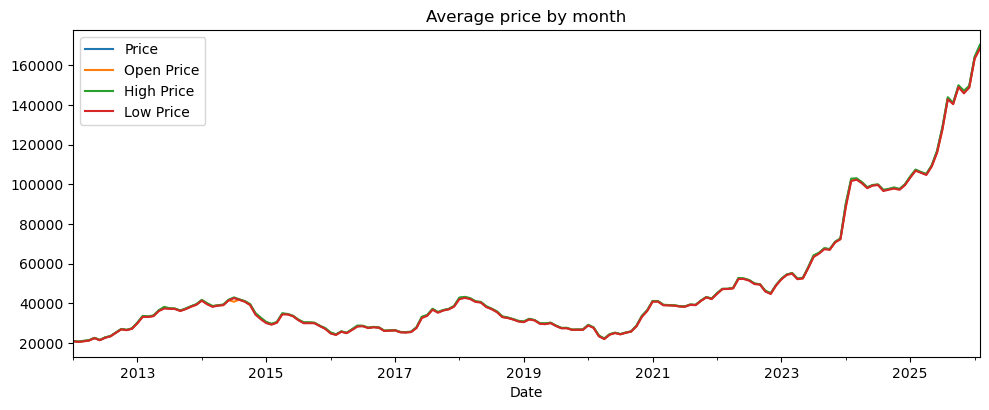

In [118]:
plt.figure(figsize=(10,4))

df.Price.resample('ME').mean().plot(label= 'Price')
df.Open.resample('ME').mean().plot(label= 'Open Price')
df.High.resample('ME').mean().plot(label= 'High Price')
df.Low.resample('ME').mean().plot(label= 'Low Price')

plt.tight_layout()
plt.legend()
plt.title('Average price by month')
plt.show()

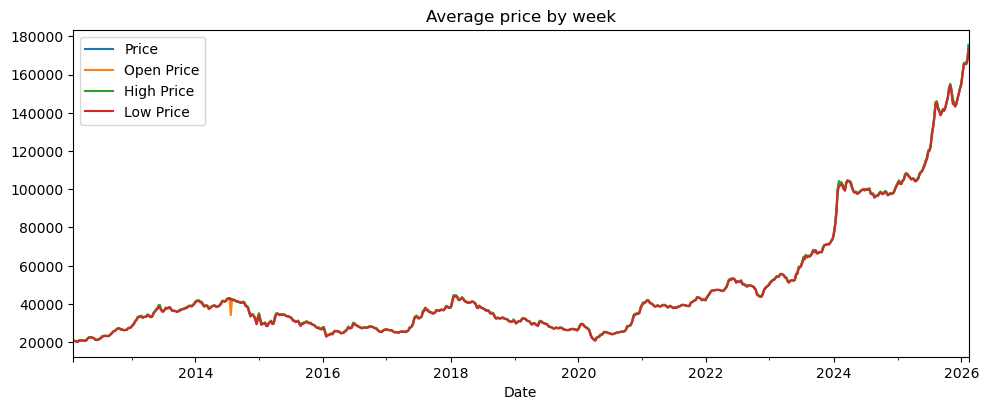

In [120]:
plt.figure(figsize=(10,4))

df.Price.resample('W').mean().plot(label= 'Price')
df.Open.resample('W').mean().plot(label= 'Open Price')
df.High.resample('W').mean().plot(label= 'High Price')
df.Low.resample('W').mean().plot(label= 'Low Price')

plt.tight_layout()
plt.legend()
plt.title('Average price by week')
plt.show()

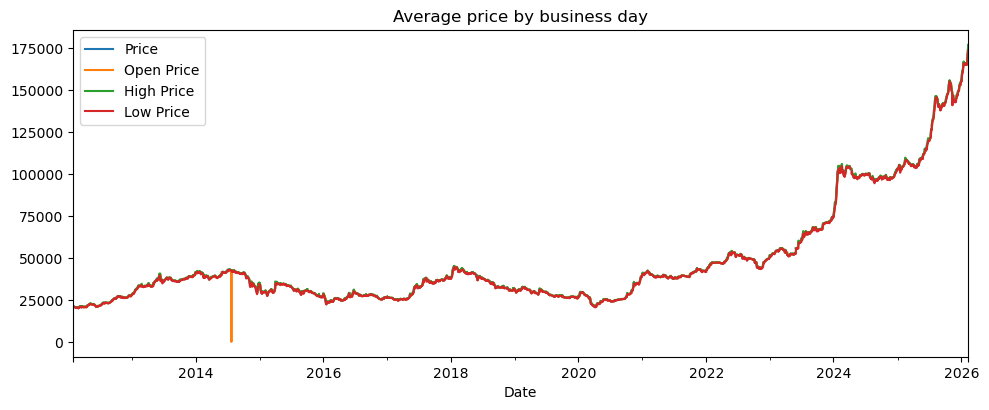

In [121]:
plt.figure(figsize=(10,4))

df.Price.resample('B').mean().plot(label= 'Price')
df.Open.resample('B').mean().plot(label= 'Open Price')
df.High.resample('B').mean().plot(label= 'High Price')
df.Low.resample('B').mean().plot(label= 'Low Price')

plt.tight_layout()
plt.legend()
plt.title('Average price by business day')
plt.show()

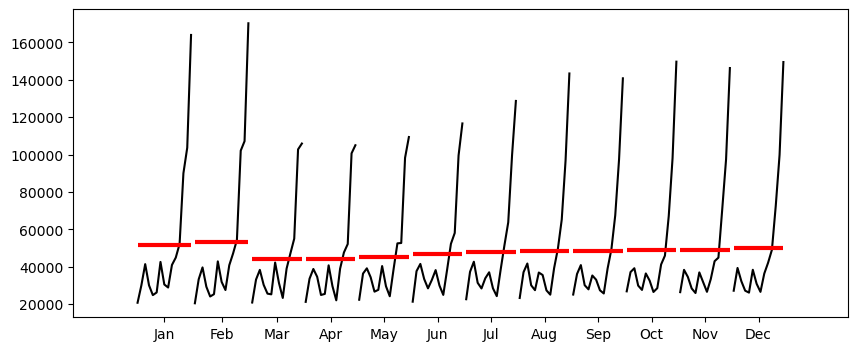

In [129]:

month_plot(df.Price.resample('ME').mean()).set_size_inches(10,4)

plt.show()

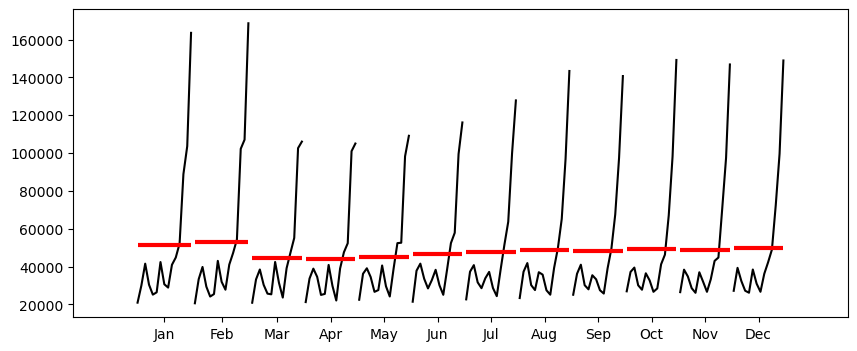

In [130]:

month_plot(df.Open.resample('ME').mean()).set_size_inches(10,4)

plt.show()

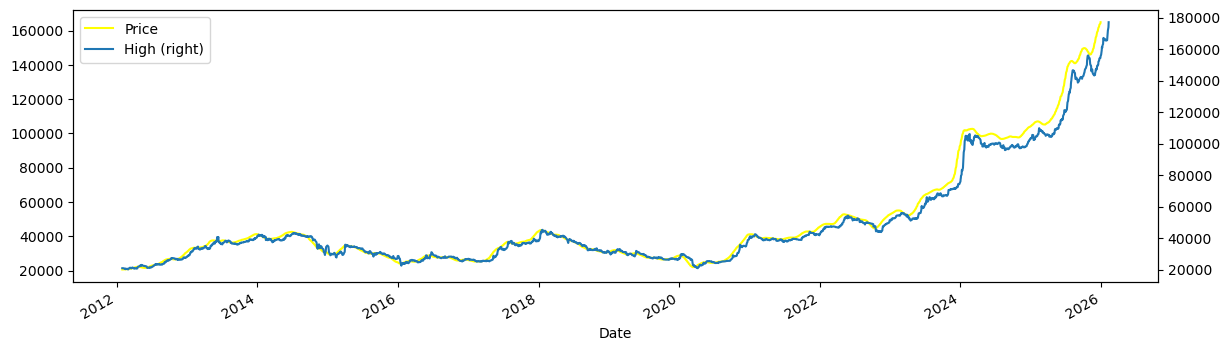

In [138]:
# Plot closing price and 30 day rolling volume
plt.figure(figsize=(14, 4))
df.Price.rolling(window=30).mean().plot(legend= True, color= 'yellow')

df.High.plot(secondary_y= True, legend= True)

plt.show()